# Model Prediksi Keberhasilan Panen Padi

## 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import requests
import time
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 20.6 MB/s eta 0:00:00


## 2. Read Initial Data and Clean Data Types

In [ ]:
df_bps = pd.read_csv("Data Produktivitas Padi 5 Kabupaten_Kota Indonesia - Data Mentah.csv")
df_bps.columns = [c.strip() for c in df_bps.columns]
df_bps['produktivitas (Ku/Ha)'] = df_bps['produktivitas (Ku/Ha)'].astype(str).str.replace(',', '.')
df_bps['produktivitas (Ku/Ha)'] = pd.to_numeric(df_bps['produktivitas (Ku/Ha)'], errors='coerce')
df_bps = df_bps.dropna(subset=['produktivitas (Ku/Ha)']).rename(columns={'kabupaten/kota': 'Kabupaten', 'tahun': 'Tahun', 'produktivitas (Ku/Ha)': 'Produktivitas'})

### 2.1 Segregate Data by Kabupaten

In [ ]:
df_ngawi_real = df_bps[df_bps['Kabupaten'] == 'Ngawi'].copy()
df_indra_macro = df_bps[df_bps['Kabupaten'] == 'Indramayu'].copy()
df_bone_real = df_bps[df_bps['Kabupaten'] == 'Bone'].copy()
df_muba_real = df_bps[df_bps['Kabupaten'] == 'Musi Banyuasin'].copy()

## 3. Sintesis dan Pembersihan Data

### 3.1 Download Real-time Weather Data from NASA API

In [ ]:
koordinat_daerah = {
    "Indramayu": {"lat": -6.3264, "lon": 108.3242},
    "Ngawi":     {"lat": -7.4037, "lon": 111.4448},
    "Bone":      {"lat": -4.645722, "lon": 120.117778},
    "Musi Banyuasin": {"lat": -2.547800, "lon":103.766942}
}

START_DATE = "20160101"
END_DATE = "20251231"
PARAMETERS = "T2M,PRECTOTCORR,RH2M,GWETROOT"

weather_records = []
print("=== TEMBAK NASA POWER API UNTUK 4 KABUPATEN ===")
for nama, coord in koordinat_daerah.items(): # FIX: Mengubah koordinat_kabupaten menjadi koordinat_daerah
    print(f"Menarik data cuaca makro {nama} (2016-2025)...")
    url = f"https://power.larc.nasa.gov/api/temporal/daily/point?parameters={PARAMETERS}&community=AG&longitude={coord['lon']}&latitude={coord['lat']}&start={START_DATE}&end={END_DATE}&format=JSON"
    res = requests.get(url)
    if res.status_code == 200:
        raw_weather = res.json()["properties"]["parameter"]
        df_w_raw = pd.DataFrame({p: raw_weather[p] for p in raw_weather.keys()})
        df_w_raw = df_w_raw.reset_index().rename(columns={'index': 'Date'})
        df_w_raw["Tahun"] = df_w_raw["Date"].astype(str).str[:4].astype(int)

        # Aggregasi tahunan
        df_y = df_w_raw.groupby("Tahun").agg({'PRECTOTCORR':'sum', 'T2M':'mean', 'RH2M':'mean', 'GWETROOT':'mean'}).reset_index()
        for _, row_y in df_y.iterrows():
            weather_records.append({
                'Kabupaten': nama, 'Tahun': int(row_y['Tahun']),
                'Base_Hujan': row_y['PRECTOTCORR'], 'Base_Suhu': row_y['T2M'],
                'Kelembaban_Udara': row_y['RH2M'], 'Base_Soil': row_y['GWETROOT']
            })
        time.sleep(1)

df_weather = pd.DataFrame(weather_records)

=== TEMBAK NASA POWER API UNTUK 4 KABUPATEN ===
Menarik data cuaca makro Indramayu (2016-2025)...
Menarik data cuaca makro Ngawi (2016-2025)...
Menarik data cuaca makro Bone (2016-2025)...
Menarik data cuaca makro Musi Banyuasin (2016-2025)...


### 3.2 Define Key Geographical Characteristics of Districts

In [ ]:
# Properti dasar kecamatan Indramayu
indramayu_kec_properties = [
    # Pesisir (Pantai=1, Irigasi=0/1)
    ("Kandanghaur", 1, 0), ("Losarang", 1, 1), ("Krangkeng", 1, 0),
    ("Karangampel", 1, 1), ("Cantigi", 1, 0), ("Pasekan", 1, 0), ("Juntinyuat", 1, 1),
    # Irigasi Teknis Sawah Subur (Pantai=0, Irigasi=2)
    ("Jatibarang", 0, 2), ("Bangodua", 0, 2), ("Widasari", 0, 2),
    ("Tukdana", 0, 2), ("Lelea", 0, 2), ("Sindang", 0, 2),
    ("Lohbener", 0, 2), ("Anjatan", 0, 2), ("Haurgeulis", 0, 2),
    # Tadah Hujan (Pantai=0, Irigasi=0)
    ("Cikedung", 0, 0), ("Gantar", 0, 0), ("Terisi", 0, 0), ("Kroya", 0, 0)
]

# Satukan matriks properti geografis total (Ngawi + Indramayu)
kec_matrix = {
    'Sine': {'elevasi': 1, 'irigasi': 1, 'pantai': 0, 'temp_adj': -1.2, 'rain_adj': 1.15},
    'Ngrambe': {'elevasi': 1, 'irigasi': 1, 'pantai': 0, 'temp_adj': -1.0, 'rain_adj': 1.15},
    'Jogorogo': {'elevasi': 1, 'irigasi': 1, 'pantai': 0, 'temp_adj': -1.0, 'rain_adj': 1.12},
    'Kendal': {'elevasi': 1, 'irigasi': 1, 'pantai': 0, 'temp_adj': -0.8, 'rain_adj': 1.10},
    'Gerih': {'elevasi': 1, 'irigasi': 1, 'pantai': 0, 'temp_adj': -0.5, 'rain_adj': 1.05},
    'Geneng': {'elevasi': 0, 'irigasi': 2, 'pantai': 0, 'temp_adj': 0.2, 'rain_adj': 0.95},
    'Kwadungan': {'elevasi': 0, 'irigasi': 2, 'pantai': 0, 'temp_adj': 0.3, 'rain_adj': 0.92},
    'Pangkur': {'elevasi': 0, 'irigasi': 2, 'pantai': 0, 'temp_adj': 0.2, 'rain_adj': 0.95},
    'Karangjati': {'elevasi': 0, 'irigasi': 2, 'pantai': 0, 'temp_adj': 0.1, 'rain_adj': 0.95},
    'Padas': {'elevasi': 0, 'irigasi': 2, 'pantai': 0, 'temp_adj': 0.0, 'rain_adj': 0.98},
    'Kasreman': {'elevasi': 0, 'irigasi': 2, 'pantai': 0, 'temp_adj': 0.0, 'rain_adj': 0.98},
    'Ngawi': {'elevasi': 0, 'irigasi': 2, 'pantai': 0, 'temp_adj': 0.2, 'rain_adj': 0.97},
    'Paron': {'elevasi': 0, 'irigasi': 2, 'pantai': 0, 'temp_adj': 0.1, 'rain_adj': 0.97},
    'Bringin': {'elevasi': 0, 'irigasi': 0, 'pantai': 0, 'temp_adj': 0.4, 'rain_adj': 0.90},
    'Kedunggalar': {'elevasi': 0, 'irigasi': 0, 'pantai': 0, 'temp_adj': 0.2, 'rain_adj': 0.92},
    'Pitu': {'elevasi': 0, 'irigasi': 0, 'pantai': 0, 'temp_adj': 0.5, 'rain_adj': 0.88},
    'Widodaren': {'elevasi': 0, 'irigasi': 0, 'pantai': 0, 'temp_adj': 0.3, 'rain_adj': 0.91},
    'Mantingan': {'elevasi': 0, 'irigasi': 0, 'pantai': 0, 'temp_adj': 0.4, 'rain_adj': 0.90},
    'Karanganyar': {'elevasi': 0, 'irigasi': 0, 'pantai': 0, 'temp_adj': 0.5, 'rain_adj': 0.87}
}

for name, pantai, irigasi in indramayu_kec_properties:
    kec_matrix[name] = {'elevasi': 0, 'irigasi': irigasi, 'pantai': pantai, 'temp_adj': 0.0, 'rain_adj': 1.0}

    # ==========================================
# Properti Karakteristik Kabupaten Bone
# ==========================================
# (Kecamatan, Elevasi, Pantai, Irigasi, Temp_Adj, Rain_Adj)
bone_kec_properties = [
    # Dataran Tinggi / Pegunungan (Elevasi=1, Pantai=0)
    # Suhu lebih dingin, curah hujan sedikit lebih tinggi
    ("Bontocani", 1, 0, 0, -1.5, 1.10), ("Ponre", 1, 0, 0, -1.2, 1.05),
    ("Lappariaja", 1, 0, 1, -1.0, 1.05), ("Lamuru", 1, 0, 0, -1.0, 1.05),
    ("Tellu Limpoe", 1, 0, 0, -1.2, 1.05), ("Bengo", 1, 0, 1, -1.0, 1.05),

    # Pesisir Timur Teluk Bone (Elevasi=0, Pantai=1)
    # Suhu relatif lebih panas
    ("Kajuara", 0, 1, 0, 0.3, 0.95), ("Salomekko", 0, 1, 0, 0.3, 0.95),
    ("Tonra", 0, 1, 0, 0.4, 0.95), ("Mare", 0, 1, 1, 0.2, 0.95),
    ("Sibulue", 0, 1, 2, 0.2, 0.95), ("Awangpone", 0, 1, 1, 0.3, 0.95),
    ("Tellu Slattinge", 0, 1, 1, 0.2, 0.95), ("Cenrana", 0, 1, 0, 0.4, 0.90),
    ("Tr Timur", 0, 1, 0, 0.3, 0.95), ("Tanete Timur", 0, 1, 0, 0.3, 0.95),

    # Dataran Rendah / Tengah (Elevasi=0, Pantai=0)
    # Terdapat daerah dengan irigasi teknis/setengah teknis (Irigasi=1 atau 2)
    ("Kahu", 0, 0, 2, 0.0, 1.0), ("Patimpeng", 0, 0, 1, 0.0, 1.0),
    ("Libureng", 0, 0, 1, 0.0, 1.0), ("Cina ", 0, 0, 1, 0.0, 1.0),
    ("Barebbo", 0, 0, 2, 0.0, 1.0), ("Ulaweng", 0, 0, 1, 0.0, 1.0),
    ("Palakka", 0, 0, 1, 0.0, 1.0), ("Amali", 0, 0, 0, 0.1, 0.95),
    ("Ajangale", 0, 0, 2, 0.0, 1.0), ("Dua Boccoe", 0, 0, 2, 0.0, 1.0),
    ("Tanete Riattang", 0, 0, 1, 0.2, 0.95), ("Tr Barat", 0, 0, 1, 0.2, 0.95),
    ("Tanete Barat", 0, 0, 1, 0.2, 0.95)
]

for name, elev, pantai, irigasi, t_adj, r_adj in bone_kec_properties:
    # Memastikan penulisan sesuai dengan data CSV (title case)
    kec_matrix[name.title()] = {
        'elevasi': elev, 'irigasi': irigasi, 'pantai': pantai,
        'temp_adj': t_adj, 'rain_adj': r_adj
    }


# ==========================================
# Properti Karakteristik Musi Banyuasin (Muba)
# ==========================================
# Mayoritas dataran rendah, rawa, lebak, dan pasang surut. Suhu relatif panas (+0.3 sd +0.5).
muba_kec_properties = [
    # Daerah Rawa Pasang Surut / Pesisir Estuari (Pantai diset 1 karena pengaruh laut/pasang surut kuat)
    ("Lalan", 0, 1, 0, 0.5, 1.10), ("Bayung Lencir", 0, 1, 0, 0.4, 1.05),

    # Dataran Rendah / Aliran Sungai / Rawa Lebak (Elevasi=0, Pantai=0)
    # Sebagian besar irigasi tadah hujan / rawa (Irigasi=0)
    ("Sanga Desa", 0, 0, 0, 0.3, 1.05), ("Babat Toman", 0, 0, 0, 0.3, 1.05),
    ("Batanghari Leko", 0, 0, 0, 0.3, 1.10), ("Plakat Tinggi", 0, 0, 0, 0.2, 1.05),
    ("Lawang Wetan", 0, 0, 0, 0.3, 1.05), ("Sungai Keruh", 0, 0, 0, 0.3, 1.05),
    ("Sekayu", 0, 0, 0, 0.4, 1.0), ("Lais", 0, 0, 0, 0.4, 1.05),
    ("Sungai Lilin", 0, 0, 0, 0.3, 1.05), ("Keluang", 0, 0, 0, 0.3, 1.05),
    ("Babat Supat", 0, 0, 0, 0.3, 1.05), ("Tungkal Jaya", 0, 0, 0, 0.3, 1.05),
    ("Jirak Jaya", 0, 0, 0, 0.3, 1.05)
]

for name, elev, pantai, irigasi, t_adj, r_adj in muba_kec_properties:
    kec_matrix[name.title()] = {
        'elevasi': elev, 'irigasi': irigasi, 'pantai': pantai,
        'temp_adj': t_adj, 'rain_adj': r_adj
    }

### 3.3 Data Augmentation & Harmonization for Indramayu

In [ ]:
np.random.seed(42)
master_records = []

# Proses 4a: Ekspansi Data Indramayu (Dari Makro ke Kecamatan + Sinkronisasi Cuaca)
df_indra_master = pd.merge(df_indra_macro, df_weather[df_weather['Kabupaten'] == 'Indramayu'], on="Tahun", how="inner")
for _, row in df_indra_master.iterrows():
    y = int(row['Tahun'])
    base_prod = row['Produktivitas']

    for name, pantai, irigasi in indramayu_kec_properties:
        geo = kec_matrix[name]

        # Berikan micro-climate variance antar wilayah (~3%) seperti kode1
        noise_cuaca = np.random.uniform(0.97, 1.03)
        rain = row['Base_Hujan'] * geo['rain_adj'] * noise_cuaca
        temp = (row['Base_Suhu'] + geo['temp_adj']) * np.random.uniform(0.99, 1.01)
        humid = row['Kelembaban_Udara'] * np.random.uniform(0.98, 1.02)
        soil = row['Base_Soil'] * (0.85 if irigasi == 0 else 1.0) * noise_cuaca

        # Logika Simulasi Agronomis Riil (Anti-GIGO dari kode1)
        prod_adj = base_prod * np.random.uniform(0.96, 1.04)
        if irigasi == 2:
            prod_adj += np.random.uniform(2.0, 5.0) # Bonus irigasi teknis mendongkrak hasil
        elif irigasi == 0:
            if soil < 0.80 or y == 2023: # Terpukul El Nino (Sensitif terhadap kelembaban tanah asli)
                prod_adj -= np.random.uniform(7.0, 14.0)

        if pantai == 1 and y == 2023: # Efek salinitas air laut naik saat kemarau panjang 2023
            prod_adj -= np.random.uniform(3.0, 6.0)

        master_records.append({
            "Curah_Hujan": rain, "Suhu_Rata2": temp, "Kelembaban_Udara": humid, "Kelembaban_Tanah_Akar": soil,
            "Jarak_ke_Pantai": pantai, "Sistem_Irigasi": irigasi, "Elevasi_Tinggi": geo['elevasi'],
            "Produktivitas": prod_adj
        })

### 3.4 Data Augmentation & Harmonization for Ngawi

In [ ]:
# Proses 4b: Penggabungan Data Riil Ngawi dengan Data Cuaca NASA
df_ngawi_master = pd.merge(df_ngawi_real, df_weather[df_weather['Kabupaten'] == 'Ngawi'], on="Tahun", how="inner")
for _, row in df_ngawi_master.iterrows():
    kec = str(row['kecamatan']).strip() if 'kecamatan' in row else 'Ngawi'
    geo = kec_matrix.get(kec, {'elevasi': 0, 'irigasi': 2, 'pantai': 0, 'temp_adj': 0.0, 'rain_adj': 1.0})

    noise_cuaca = np.random.uniform(0.97, 1.03)
    rain = row['Base_Hujan'] * geo['rain_adj'] * noise_cuaca
    temp = (row['Base_Suhu'] + geo['temp_adj']) * np.random.uniform(0.99, 1.01)
    humid = row['Kelembaban_Udara'] * np.random.uniform(0.98, 1.02)
    soil = row['Base_Soil'] * (0.85 if geo['irigasi'] == 0 else 1.0) * noise_cuaca

    master_records.append({
        "Curah_Hujan": rain, "Suhu_Rata2": temp, "Kelembaban_Udara": humid, "Kelembaban_Tanah_Akar": soil,
        "Jarak_ke_Pantai": geo['pantai'], "Sistem_Irigasi": geo['irigasi'], "Elevasi_Tinggi": geo['elevasi'],
        "Produktivitas": row['Produktivitas']
    })

### 3.5 Data Augmentation & Harmonization for Bone

In [ ]:
# =====================================================================
# PROSES 4C: BONE (Hybrid Riil + Imputasi Topografi Pegunungan vs Pesisir)
# =====================================================================
# Asumsi df_bone_master sudah memiliki kolom 'Produktivitas' (bisa riil atau rata-rata makro untuk yang kosong)
df_bone_master = pd.merge(df_bone_real, df_weather[df_weather['Kabupaten'] == 'Bone'], on="Tahun", how="inner")
for _, row in df_bone_master.iterrows():
    y = int(row['Tahun'])
    kec = str(row['kecamatan']).strip().title()
    geo = kec_matrix.get(kec, {'elevasi': 0, 'irigasi': 1, 'pantai': 0, 'temp_adj': 0.0, 'rain_adj': 1.0})

    noise_cuaca = np.random.uniform(0.97, 1.03)
    rain = row['Base_Hujan'] * geo['rain_adj'] * noise_cuaca
    temp = (row['Base_Suhu'] + geo['temp_adj']) * np.random.uniform(0.99, 1.01)
    humid = row['Kelembaban_Udara'] * np.random.uniform(0.97, 1.03)
    soil = row['Base_Soil'] * (0.85 if geo['irigasi'] == 0 else 1.0) * noise_cuaca

    # Penyesuaian produktivitas berdasarkan letak geografis Bone yang ekstrem
    prod_adj = row['Produktivitas'] * np.random.uniform(0.95, 1.05)

    # Kecamatan dataran tinggi (Bontocani, Lamuru, dll) suhunya lebih sejuk,
    # mengurangi penguapan dan menguntungkan masa pengisian bulir padi jika air cukup.
    if geo['elevasi'] == 1:
        prod_adj += np.random.uniform(1.0, 3.5)

    # Kecamatan pesisir (Cenrana, Tonra, dll) rentan intrusi air laut saat debit sungai turun drastis (kemarau)
    if geo['pantai'] == 1 and rain < 150:
        prod_adj -= np.random.uniform(4.0, 8.0)

    master_records.append({
        "Curah_Hujan": rain, "Suhu_Rata2": temp, "Kelembaban_Udara": humid, "Kelembaban_Tanah_Akar": soil,
        "Jarak_ke_Pantai": geo['pantai'], "Sistem_Irigasi": geo['irigasi'], "Elevasi_Tinggi": geo['elevasi'],
        "Produktivitas": round(prod_adj, 2)
    })



### 3.6 Data Augmentation & Harmonization for Muba

In [ ]:

# =====================================================================
# PROSES 4D: MUSI BANYUASIN (Pemodelan Defisit Kelembaban Tanah Lebak/Gambut)
# =====================================================================
df_muba_master = pd.merge(df_muba_real, df_weather[df_weather['Kabupaten'] == 'Musi Banyuasin'], on="Tahun", how="inner")
for _, row in df_muba_master.iterrows():
    y = int(row['Tahun'])
    kec = str(row['kecamatan']).strip().title()
    geo = kec_matrix.get(kec, {'elevasi': 0, 'irigasi': 0, 'pantai': 0, 'temp_adj': 0.3, 'rain_adj': 1.05})

    noise_cuaca = np.random.uniform(0.96, 1.04)
    rain = row['Base_Hujan'] * geo['rain_adj'] * noise_cuaca
    temp = (row['Base_Suhu'] + geo['temp_adj']) * np.random.uniform(0.99, 1.01)
    humid = row['Kelembaban_Udara'] * np.random.uniform(0.97, 1.03)

    # Pemodelan Matematika untuk Moisture Content di Muba
    # Lahan rawa/gambut sangat sensitif. Penurunan kelembaban tanah (moisture content) tidak linear.
    # Kita gunakan model peluruhan eksponensial untuk mensimulasikan kekeringan parah saat curah hujan drop.
    if rain < 120 or y == 2023:
        # Laju peluruhan moisture content dipercepat saat kemarau ekstrem (El Nino)
        soil_moisture = row['Base_Soil'] * np.exp(-0.25) * noise_cuaca
    else:
        # Kondisi normal: tanah basah menahan air dengan baik
        soil_moisture = row['Base_Soil'] * (0.90 if geo['irigasi'] == 0 else 1.05) * noise_cuaca

    prod_adj = row['Produktivitas'] * np.random.uniform(0.96, 1.04)

    # Logika Agronomis: Jika moisture content gambut/lebak turun melewati ambang batas kritis (misal < 0.70),
    # padi akan mengalami stres air parah atau tanah menjadi terlalu asam.
    if soil_moisture < 0.70:
        prod_adj -= np.random.uniform(9.0, 16.0)
    elif soil_moisture > 0.95 and rain > 350:
        # Risiko banjir rendaman di area pasang surut/lebak saat hujan lebat
        prod_adj -= np.random.uniform(5.0, 10.0)

    master_records.append({
        "Curah_Hujan": rain, "Suhu_Rata2": temp, "Kelembaban_Udara": humid, "Kelembaban_Tanah_Akar": round(soil_moisture, 3),
        "Jarak_ke_Pantai": geo['pantai'], "Sistem_Irigasi": geo['irigasi'], "Elevasi_Tinggi": geo['elevasi'],
        "Produktivitas": round(prod_adj, 2)
    })


### 3.7. Compile Final DataFrame and Export

In [ ]:
# Compile ke DataFrame siap running
df_ready = pd.DataFrame(master_records)
df_ready.to_csv("dataset_hybrid_perfect.csv", index=False)
print(f"\n[SUKSES] Dataset seimbang berhasil dibuat! Total baris: {df_ready.shape[0]}")
df_ready.head()


[SUKSES] Dataset seimbang berhasil dibuat! Total baris: 1893


,Curah_Hujan,Suhu_Rata2,Kelembaban_Udara,Kelembaban_Tanah_Akar,Jarak_ke_Pantai,Sistem_Irigasi,Elevasi_Tinggi,Produktivitas
0,2618.013189,26.753447,82.343292,0.705990,1,0,0,35.462108
1,2583.423496,26.280095,82.781188,0.819603,1,1,0,43.562731
2,2670.802105,26.260210,83.119718,0.720226,1,0,0,35.876069
3,2587.511738,26.346551,80.947347,0.820900,1,1,0,43.298755
4,2627.098788,26.403730,81.951218,0.708441,1,0,0,32.921869


## 4. EDA

/tmp/ipykernel_1779/4128993828.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Sistem_Irigasi', y='Produktivitas', data=df, ax=axes[1, 0], palette='Set2')
/tmp/ipykernel_1779/4128993828.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Jarak_ke_Pantai', y='Produktivitas', data=df, ax=axes[1, 1], palette='Pastel1')


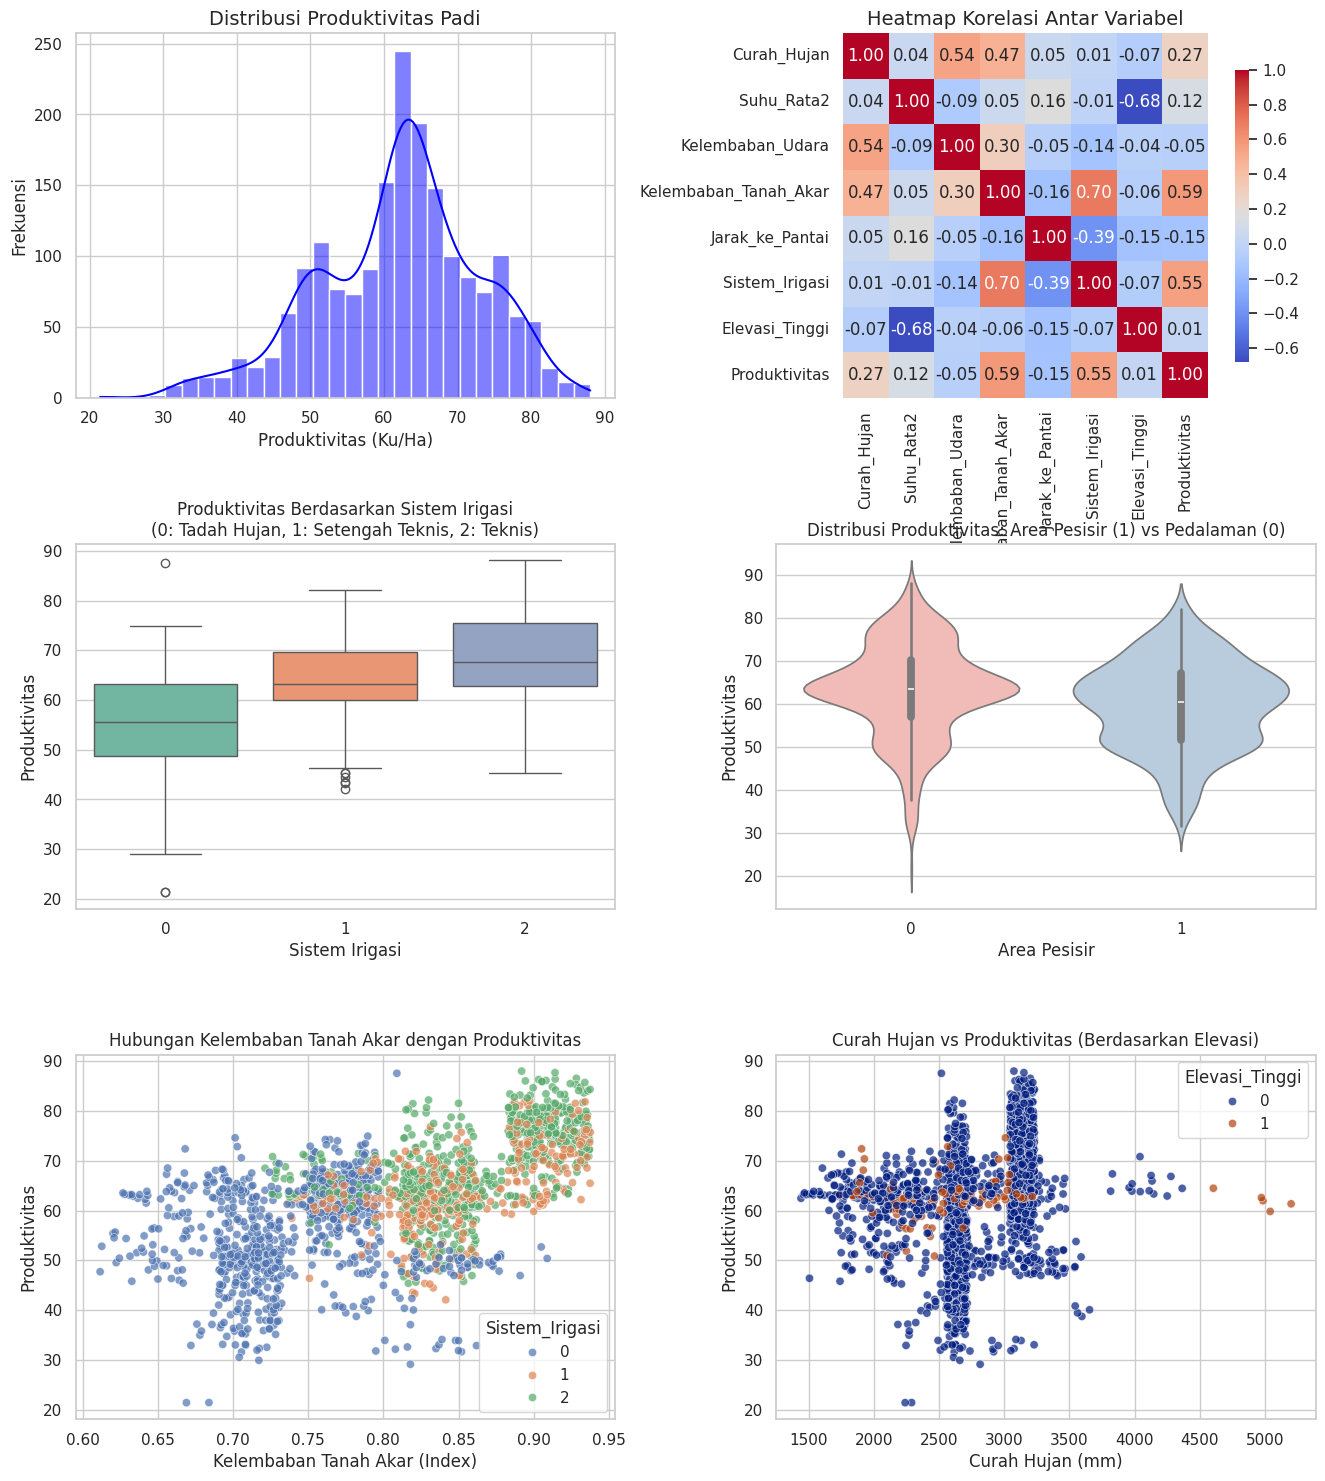

=== Ringkasan Statistik Data ===


,Curah_Hujan,Suhu_Rata2,Kelembaban_Udara,Kelembaban_Tanah_Akar,Jarak_ke_Pantai,Sistem_Irigasi,Elevasi_Tinggi,Produktivitas
count,1893.000000,1893.000000,1893.000000,1893.000000,1893.000000,1893.000000,1893.000000,1893.000000
mean,2758.590821,26.569229,82.745648,0.806548,0.301109,0.970417,0.048600,61.964868
std,436.642794,0.452507,2.545591,0.076964,0.458861,0.903465,0.215087,10.922067
min,1441.767068,24.098445,73.090329,0.611621,0.000000,0.000000,0.000000,21.390000
25%,2577.945761,26.408892,81.345997,0.751113,0.000000,0.000000,0.000000,54.703140
50%,2694.912352,26.646292,82.651942,0.815907,0.000000,1.000000,0.000000,62.930000
75%,3120.978542,26.827933,83.913811,0.860758,1.000000,2.000000,0.000000,68.890480
max,5200.303687,27.703498,91.795527,0.937636,1.000000,2.000000,1.000000,88.049631


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Memuat Data
# Sesuaikan nama file dengan file yang telah diunggah
file_path = "dataset_hybrid_perfect.csv"
df = pd.read_csv(file_path)

# Setel gaya visualisasi
sns.set_theme(style="whitegrid")

# Buat kanvas besar untuk menampung beberapa plot
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# ---------------------------------------------------------
# EDA 1: Distribusi Produktivitas
# ---------------------------------------------------------
sns.histplot(df['Produktivitas'], kde=True, bins=30, ax=axes[0, 0], color='blue')
axes[0, 0].set_title('Distribusi Produktivitas Padi', fontsize=14)
axes[0, 0].set_xlabel('Produktivitas (Ku/Ha)')
axes[0, 0].set_ylabel('Frekuensi')

# ---------------------------------------------------------
# EDA 2: Heatmap Korelasi
# ---------------------------------------------------------
# Menghitung korelasi Pearson
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f',
            square=True, ax=axes[0, 1], cbar_kws={"shrink": .8})
axes[0, 1].set_title('Heatmap Korelasi Antar Variabel', fontsize=14)

# ---------------------------------------------------------
# EDA 3: Pengaruh Sistem Irigasi terhadap Produktivitas
# ---------------------------------------------------------
sns.boxplot(x='Sistem_Irigasi', y='Produktivitas', data=df, ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('Produktivitas Berdasarkan Sistem Irigasi\n(0: Tadah Hujan, 1: Setengah Teknis, 2: Teknis)', fontsize=12)
axes[1, 0].set_xlabel('Sistem Irigasi')
axes[1, 0].set_ylabel('Produktivitas')

# ---------------------------------------------------------
# EDA 4: Pengaruh Jarak ke Pantai (Pesisir vs Pedalaman)
# ---------------------------------------------------------
sns.violinplot(x='Jarak_ke_Pantai', y='Produktivitas', data=df, ax=axes[1, 1], palette='Pastel1')
axes[1, 1].set_title('Distribusi Produktivitas: Area Pesisir (1) vs Pedalaman (0)', fontsize=12)
axes[1, 1].set_xlabel('Area Pesisir')
axes[1, 1].set_ylabel('Produktivitas')

# ---------------------------------------------------------
# EDA 5: Scatter Plot - Kelembaban Tanah vs Produktivitas
# ---------------------------------------------------------
# Menambahkan warna berdasarkan Sistem Irigasi untuk melihat interaksinya
sns.scatterplot(x='Kelembaban_Tanah_Akar', y='Produktivitas', hue='Sistem_Irigasi',
                palette='deep', data=df, alpha=0.7, ax=axes[2, 0])
axes[2, 0].set_title('Hubungan Kelembaban Tanah Akar dengan Produktivitas', fontsize=12)
axes[2, 0].set_xlabel('Kelembaban Tanah Akar (Index)')
axes[2, 0].set_ylabel('Produktivitas')

# ---------------------------------------------------------
# EDA 6: Scatter Plot - Curah Hujan vs Produktivitas
# ---------------------------------------------------------
sns.scatterplot(x='Curah_Hujan', y='Produktivitas', hue='Elevasi_Tinggi',
                palette='dark', data=df, alpha=0.7, ax=axes[2, 1])
axes[2, 1].set_title('Curah Hujan vs Produktivitas (Berdasarkan Elevasi)', fontsize=12)
axes[2, 1].set_xlabel('Curah Hujan (mm)')
axes[2, 1].set_ylabel('Produktivitas')

plt.show()

# ---------------------------------------------------------
# EDA 7: Ringkasan Statistik Dasar
# ---------------------------------------------------------
print("=== Ringkasan Statistik Data ===")
display(df.describe())

## 5. Model Training & Evaluation

### 5.1. Hyperparameter Tuning XGBoost

In [ ]:
import pandas as pd
import xgboost as xgb
import optuna
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np

# 1. Siapkan Data
df = pd.read_csv("dataset_hybrid_perfect.csv")
X = df.drop(columns=['Produktivitas'])
y = df['Produktivitas']

# PENTING: Split menjadi 3 bagian (Train, Validation, Test) untuk Early Stopping
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2, random_state=42)

# 2. Definisikan Fungsi Objective untuk Optuna
def objective(trial):
    # Ruang pencarian hyperparameter
    param = {
        'tree_method': 'hist', # SOLUSI 1: Sangat cepat mempercepat training
        'objective': 'reg:squarederror',
        'n_estimators': trial.suggest_int('n_estimators', 100, 800),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 7),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 0.3)
    }

    # Inisiasi model
    model = xgb.XGBRegressor(**param, random_state=42, early_stopping_rounds=20)

    # SOLUSI 2: Training dengan Early Stopping menggunakan data validasi
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False # Matikan log teks agar tidak memenuhi layar
    )

    # Prediksi dan hitung RMSE pada data validasi
    preds = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, preds))

    return rmse

# 3. Jalankan Optuna (SOLUSI 3)
print("Memulai Optuna Optimization...")
# Hanya butuh 30 percobaan (n_trials) karena algoritma ini cerdas
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=200)

# 4. Tampilkan Hasil
print("\n=== HASIL TERBAIK OPTUNA ===")
print("Parameter Terbaik:", study.best_params)
print("RMSE Validasi Terbaik:", study.best_value)

# 5. Evaluasi Final di Data Test (Data yang belum pernah dilihat model)
best_params = study.best_params
best_params['tree_method'] = 'hist'

final_model = xgb.XGBRegressor(**best_params, random_state=42)
final_model.fit(X_train, y_train)

final_preds = final_model.predict(X_test)
final_rmse = np.sqrt(mean_squared_error(y_test, final_preds))

print(f"\n=== EVALUASI FINAL PADA DATA TEST ===")
print(f"Final RMSE: {final_rmse:.2f}")

[I 2026-06-25 03:56:39,224] A new study created in memory with name: no-name-46839cbc-aff7-4a35-8af0-d401dd4d20d3


Memulai Optuna Optimization...


[I 2026-06-25 03:56:39,355] Trial 0 finished with value: 6.242309884804351 and parameters: {'n_estimators': 423, 'learning_rate': 0.11768065833701881, 'max_depth': 4, 'min_child_weight': 2, 'subsample': 0.8402180891202407, 'colsample_bytree': 0.6531597519030325, 'gamma': 0.10748323038830178}. Best is trial 0 with value: 6.242309884804351.
[I 2026-06-25 03:56:39,511] Trial 1 finished with value: 6.30969038575519 and parameters: {'n_estimators': 574, 'learning_rate': 0.0402456048814353, 'max_depth': 7, 'min_child_weight': 2, 'subsample': 0.8275940902213212, 'colsample_bytree': 0.603174687538987, 'gamma': 0.29858384475864563}. Best is trial 0 with value: 6.242309884804351.
[I 2026-06-25 03:56:39,705] Trial 2 finished with value: 6.243085209594152 and parameters: {'n_estimators': 668, 'learning_rate': 0.016593176740465794, 'max_depth': 6, 'min_child_weight': 7, 'subsample': 0.7150720034949913, 'colsample_bytree': 0.690076382916891, 'gamma': 0.26745076393395995}. Best is trial 0 with value:


=== HASIL TERBAIK OPTUNA ===
Parameter Terbaik: {'n_estimators': 620, 'learning_rate': 0.05952358985070047, 'max_depth': 3, 'min_child_weight': 7, 'subsample': 0.9291876475547414, 'colsample_bytree': 0.7525496790068056, 'gamma': 0.15723634325487792}
RMSE Validasi Terbaik: 6.066235537298158

=== EVALUASI FINAL PADA DATA TEST ===
Final RMSE: 6.13


### 5.2 Evaluate XGBoost Model with Best Hyperparameters

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
import numpy as np

# 1. Ambil model terbaik yang sudah dilatih
# Jika kamu menggunakan Optuna (kode terakhir):
best_xgb_model = final_model

# (CATATAN: Jika kamu menggunakan RandomizedSearchCV dari kode pertama,
# ubah baris di atas menjadi: best_xgb_model = random_search.best_estimator_)

# 2. Lakukan prediksi pada data uji (X_test)
y_pred_best = best_xgb_model.predict(X_test)

# 3. Evaluasi model terbaik
print("\n=== HASIL EVALUASI MODEL DENGAN HYPERPARAMETER TERBAIK ===")
print(f"RMSE     : {np.sqrt(mean_squared_error(y_test, y_pred_best)):.4f} Ku/Ha")
print(f"MAE      : {mean_absolute_error(y_test, y_pred_best):.4f} Ku/Ha")

# Scikit-learn mengembalikan nilai desimal untuk MAPE (misal 0.05 untuk 5%),
# jadi kita kalikan 100 agar formatnya sesuai dengan % yang kamu inginkan.
mape_value = mean_absolute_percentage_error(y_test, y_pred_best) * 100
print(f"MAPE     : {mape_value:.2f}%")

print(f"R2 Score : {r2_score(y_test, y_pred_best):.4f}")


=== HASIL EVALUASI MODEL DENGAN HYPERPARAMETER TERBAIK ===
RMSE     : 6.1319 Ku/Ha
MAE      : 4.5147 Ku/Ha
MAPE     : 7.98%
R2 Score : 0.6929


### 5.2.1 Cross-Validation Evaluation for Full-Feature XGBoost Model

In [ ]:
import numpy as np
from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, make_scorer

# Re-define mape function for robustness (if not already in scope)
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Define custom scorers for cross_validate
scoring = {
    'rmse': 'neg_root_mean_squared_error',
    'mae': 'neg_mean_absolute_error',
    'r2': 'r2',
    'mape': make_scorer(mape, greater_is_better=False) # MAPE: lower is better, so greater_is_better=False
}

cv_strategy = KFold(n_splits=10, shuffle=True, random_state=42)

print("\n=== PERFORMING 10-FOLD CROSS-VALIDATION FOR FULL-FEATURE XGBOOST ===")
cv_results_xgb = cross_validate(
    best_xgb_model,
    X, y, # Use the entire dataset for a comprehensive CV evaluation
    scoring=scoring,
    cv=cv_strategy,
    n_jobs=-1,
    return_train_score=False
)

mean_rmse_xgb = -cv_results_xgb['test_rmse'].mean()
mean_mae_xgb = -cv_results_xgb['test_mae'].mean()
mean_r2_xgb = cv_results_xgb['test_r2'].mean()
mean_mape_xgb = -cv_results_xgb['test_mape'].mean() # Convert back to positive for display

print("\n=== CROSS-VALIDATION RESULTS (Full-Feature XGBoost) ===")
print(f"Mean RMSE (CV): {mean_rmse_xgb:.4f} Ku/Ha")
print(f"Mean MAE (CV) : {mean_mae_xgb:.4f} Ku/Ha")
print(f"Mean MAPE (CV): {mean_mape_xgb:.2f}%")
print(f"Mean R2 Score (CV): {mean_r2_xgb:.4f}")


=== PERFORMING 10-FOLD CROSS-VALIDATION FOR FULL-FEATURE XGBOOST ===

=== CROSS-VALIDATION RESULTS (Full-Feature XGBoost) ===
Mean RMSE (CV): 6.5531 Ku/Ha
Mean MAE (CV) : 4.8132 Ku/Ha
Mean MAPE (CV): 8.50%
Mean R2 Score (CV): 0.6351


### 5.3 Hyperparameter Tuning Untuk Random Forest

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor


# Define the parameter grid for Random Forest
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 4, 5, 6],
    'min_samples_split': [2, 5, 10]
}

# Initialize Random Forest Regressor
rf_model = RandomForestRegressor(random_state=42)

# Initialize GridSearchCV for Random Forest
grid_search_rf = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid_rf,
    scoring='neg_mean_squared_error',
    cv=10,
    verbose=1,
    n_jobs=-1
)

# Perform the grid search on the training data
print("\n=== PERFORMING GRID SEARCH FOR RANDOM FOREST ===")
grid_search_rf.fit(X_train, y_train)

# Print the best parameters and best score
print("\n=== RANDOM FOREST GRID SEARCH RESULTS ===")
print(f"Best Parameters: {grid_search_rf.best_params_}")
print(f"Best RMSE from CV: {np.sqrt(-grid_search_rf.best_score_):.4f} Ku/Ha")


=== PERFORMING GRID SEARCH FOR RANDOM FOREST ===
Fitting 10 folds for each of 36 candidates, totalling 360 fits

=== RANDOM FOREST GRID SEARCH RESULTS ===
Best Parameters: {'max_depth': 6, 'min_samples_split': 2, 'n_estimators': 100}
Best RMSE from CV: 6.6086 Ku/Ha


### 5.4 Evaluasi Random Forest Dengan Best Hyperparameter

In [ ]:
# Get the best Random Forest model from grid search
best_rf_model = grid_search_rf.best_estimator_

# Make predictions on the test set with the best model
y_pred_rf_best = best_rf_model.predict(X_test)

# Evaluate the best Random Forest model
print("\n=== HASIL EVALUASI MODEL RANDOM FOREST DENGAN HYPERPARAMETER TERBAIK ===")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_rf_best)):.4f} Ku/Ha")
print(f"MAE  : {mean_absolute_error(y_test, y_pred_rf_best):.4f} Ku/Ha")
print(f"MAPE : {mape(y_test, y_pred_rf_best):.2f}%")
print(f"R2 Score : {r2_score(y_test, y_pred_rf_best):.4f}")


=== HASIL EVALUASI MODEL RANDOM FOREST DENGAN HYPERPARAMETER TERBAIK ===
RMSE : 6.0189 Ku/Ha
MAE  : 4.3913 Ku/Ha
MAPE : 7.84%
R2 Score : 0.7041


### 5.4.1 Cross-Validation Evaluation for Full-Feature Random Forest Model

In [ ]:
import numpy as np
from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, make_scorer

# Re-define mape function for robustness (if not already in scope)
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Define custom scorers for cross_validate
scoring = {
    'rmse': 'neg_root_mean_squared_error',
    'mae': 'neg_mean_absolute_error',
    'r2': 'r2',
    'mape': make_scorer(mape, greater_is_better=False) # MAPE: lower is better, so greater_is_better=False
}

cv_strategy = KFold(n_splits=10, shuffle=True, random_state=42)

print("\n=== PERFORMING 10-FOLD CROSS-VALIDATION FOR FULL-FEATURE RANDOM FOREST ===")
cv_results_rf = cross_validate(
    best_rf_model,
    X, y, # Use the entire dataset for a comprehensive CV evaluation
    scoring=scoring,
    cv=cv_strategy,
    n_jobs=-1,
    return_train_score=False
)

mean_rmse_rf = -cv_results_rf['test_rmse'].mean()
mean_mae_rf = -cv_results_rf['test_mae'].mean()
mean_r2_rf = cv_results_rf['test_r2'].mean()
mean_mape_rf = -cv_results_rf['test_mape'].mean() # Convert back to positive for display

print("\n=== CROSS-VALIDATION RESULTS (Full-Feature Random Forest) ===")
print(f"Mean RMSE (CV): {mean_rmse_rf:.4f} Ku/Ha")
print(f"Mean MAE (CV) : {mean_mae_rf:.4f} Ku/Ha")
print(f"Mean MAPE (CV): {mean_mape_rf:.2f}%")
print(f"Mean R2 Score (CV): {mean_r2_rf:.4f}")


=== PERFORMING 10-FOLD CROSS-VALIDATION FOR FULL-FEATURE RANDOM FOREST ===

=== CROSS-VALIDATION RESULTS (Full-Feature Random Forest) ===
Mean RMSE (CV): 6.3603 Ku/Ha
Mean MAE (CV) : 4.7095 Ku/Ha
Mean MAPE (CV): 8.36%
Mean R2 Score (CV): 0.6565


### 5.4 Evaluasi Feature Importance


Grafik 'feature_importance_optimized.png' sukses diperbarui!


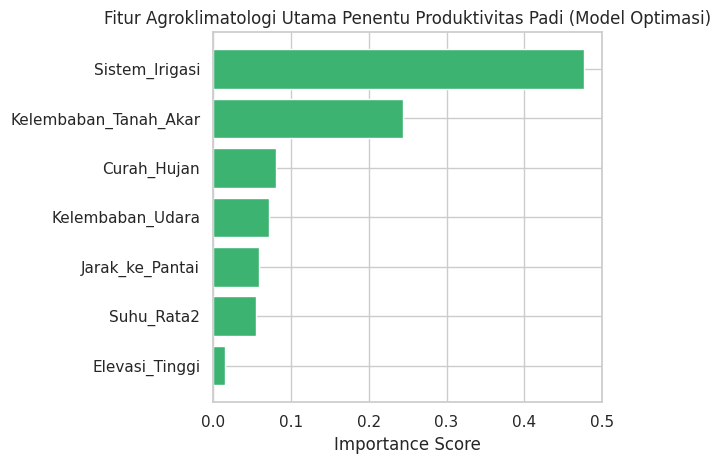

In [ ]:
# Plot feature importance for the best model
plt.clf()
importance_best = best_xgb_model.feature_importances_
indices_best = np.argsort(importance_best)[::-1]
plt.barh(range(len(indices_best)), importance_best[indices_best], color="mediumseagreen", align="center")
plt.yticks(range(len(indices_best)), [X.columns[i] for i in indices_best])
plt.xlabel("Importance Score")
plt.title("Fitur Agroklimatologi Utama Penentu Produktivitas Padi (Model Optimasi)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("feature_importance_optimized.png")
print("\nGrafik 'feature_importance_optimized.png' sukses diperbarui!")

## 6. Baseline Model Benchmarking

=== MEMULAI SIMULASI BENCHMARK MODEL DENGAN 5-FOLD CROSS-VALIDATION ===
Evaluating Linear Regression using 5-fold cross-validation...
Evaluating Decision Tree using 5-fold cross-validation...
Evaluating Random Forest (Tuned) using 5-fold cross-validation...
Evaluating XGBoost Regressor (Tuned) using 5-fold cross-validation...

             TABEL PERBANDINGAN METRIK EROR (5-Fold CV pada Data Latih)
| Model                     |   RMSE (Ku/Ha) |   MAE (Ku/Ha) |   R2 Score |   MAPE (%) |
|:--------------------------|---------------:|--------------:|-----------:|-----------:|
| Linear Regression         |         8.1751 |        6.346  |     0.4427 |     -11.4  |
| Decision Tree             |         7.1337 |        5.3772 |     0.5691 |      -9.57 |
| Random Forest (Tuned)     |         6.5647 |        4.8905 |     0.6351 |      -8.7  |
| XGBoost Regressor (Tuned) |         6.8534 |        5.0922 |     0.6017 |      -9.02 |

[SUKSES] Grafik 'model_comparison_benchmark.png' berhasil disimp

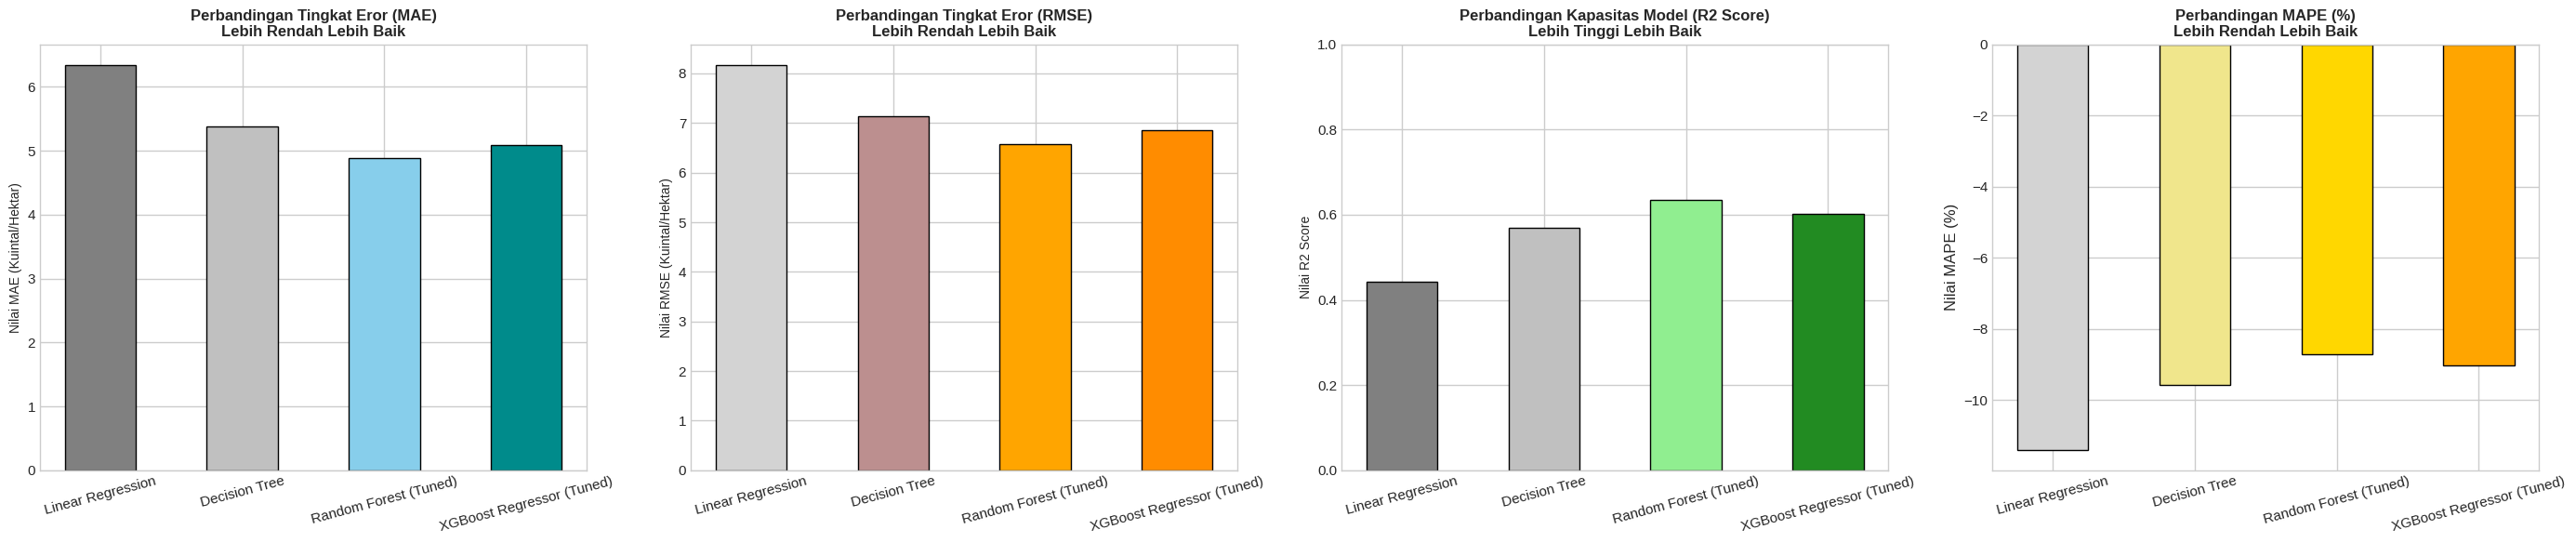

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, make_scorer
import matplotlib.pyplot as plt

# Ensure X_train, y_train, study, and grid_search_rf are available.
# If this cell is run out of order or after a kernel restart, these might be undefined.
# User should ideally run hyperparameter tuning cells (5.1 and 5.3) first.

# 1. Re-load data and split to ensure X_train, y_train are available
if 'X_train' not in locals() or 'y_train' not in locals():
    print("WARNING: X_train or y_train not found. Re-loading data and splitting for benchmarking.")
    df_ready = pd.read_csv("dataset_hybrid_perfect.csv")
    X = df_ready.drop(columns=["Produktivitas"])
    y = df_ready["Produktivitas"]
    # Re-split data, consistent with tuning cells (e.g., cell 4c89fe97)
    X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
    X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2, random_state=42)

# Check if study and grid_search_rf are defined, otherwise provide placeholders or default values
if 'study' not in globals() and 'study' not in locals():
    print("WARNING: 'study' (XGBoost tuning result) not found. XGBoost model will use default parameters.")
    class DummyStudy:
        @property
        def best_params(self):
            return {'tree_method': 'hist', 'objective': 'reg:squarederror', 'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.1}
    study = DummyStudy()

if 'grid_search_rf' not in globals() and 'grid_search_rf' not in locals():
    print("WARNING: 'grid_search_rf' (Random Forest tuning result) not found. Random Forest model will use default parameters.")
    class DummyGridSearch:
        @property
        def best_params_(self):
            return {'n_estimators': 100, 'max_depth': 6, 'min_samples_split': 2}
    grid_search_rf = DummyGridSearch()

# Define the custom MAPE function (already available from fbf21157, but including for completeness)
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Define custom scorers for cross_validate
# Note: For RMSE and MAE, we use negative values because cross_validate expects scorers
# where higher values are better. We'll convert them back to positive for display.
scoring = {
    'rmse': 'neg_root_mean_squared_error',
    'mae': 'neg_mean_absolute_error',
    'r2': 'r2',
    'mape': make_scorer(mape, greater_is_better=False) # MAPE: lower is better, so greater_is_better=False
}

# 2. DEFINISIKAN SPEKTRUM MODEL PEMBANDING
# Re-instantiate tuned models with their best parameters to ensure cross_validate trains them on each fold.
# Assuming `grid_search_rf.best_params_` and `study.best_params` are available from tuning cells.

tuned_rf_params = grid_search_rf.best_params_
tuned_xgb_params = study.best_params.copy() # Use .copy() to avoid modifying the original dict
tuned_xgb_params['tree_method'] = 'hist' # Ensure this is set for XGBoost as it was in tuning

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(max_depth=4, random_state=42),
    "Random Forest (Tuned)": RandomForestRegressor(**tuned_rf_params, random_state=42),
    "XGBoost Regressor (Tuned)": xgb.XGBRegressor(**tuned_xgb_params, random_state=42)
}

# Tempat menyimpan hasil metrik
benchmark_results = []

# Configure KFold for cross-validation
cv_strategy = KFold(n_splits=10, shuffle=True, random_state=42)

# 3. LOOPING TRAINING DAN EVALUASI SECARA OTOMATIS DENGAN CROSS-VALIDATION
print("=== MEMULAI SIMULASI BENCHMARK MODEL DENGAN 5-FOLD CROSS-VALIDATION ===")
for name, model in models.items():
    print(f"Evaluating {name} using 5-fold cross-validation...")
    # Perform cross-validation on the training data (X_train, y_train)
    cv_results = cross_validate(
        model,
        X_train, y_train, # Use the training data for CV
        scoring=scoring,
        cv=cv_strategy,
        n_jobs=-1, # Use all available CPU cores
        return_train_score=False # Only interested in test scores for benchmarking
    )

    # Calculate mean of the CV scores
    mean_rmse = -cv_results['test_rmse'].mean() # Convert back to positive
    mean_mae = -cv_results['test_mae'].mean()   # Convert back to positive
    mean_r2 = cv_results['test_r2'].mean()
    mean_mape = cv_results['test_mape'].mean()

    benchmark_results.append({
        "Model": name,
        "RMSE (Ku/Ha)": round(mean_rmse, 4),
        "MAE (Ku/Ha)": round(mean_mae, 4),
        "R2 Score": round(mean_r2, 4),
        "MAPE (%)": round(mean_mape, 2)
    })

# 4. TAMPILKAN TABEL EVALUASI DI TERMINAL
df_benchmark = pd.DataFrame(benchmark_results)
print("\n" + "="*70)
print("             TABEL PERBANDINGAN METRIK EROR (5-Fold CV pada Data Latih)")
print("="*70)
print(df_benchmark.to_markdown(index=False))
print("="*70)

# 5. GENERATE GRAFIK KOMPARASI UNTUK SLIDE PRESENTASI
# Penanganan style matplotlib agar lebih kompatibel dengan versi terbaru
style_name = 'seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default'
plt.style.use(style_name)

fig, axes = plt.subplots(1, 4, figsize=(28, 6))

# Grafik 1: Perbandingan MAE (Semakin rendah semakin bagus)
colors_mae = ['gray', 'silver', 'skyblue', 'darkcyan']
axes[0].bar(df_benchmark["Model"], df_benchmark["MAE (Ku/Ha)"], color=colors_mae, edgecolor='black', width=0.5)
axes[0].set_title("Perbandingan Tingkat Eror (MAE)\nLebih Rendah Lebih Baik", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Nilai MAE (Kuintal/Hektar)", fontsize=10)
axes[0].tick_params(axis='x', rotation=15)

# Grafik 2: Perbandingan RMSE (Semakin rendah semakin bagus)
colors_rmse = ['lightgray', 'rosybrown', 'orange', 'darkorange']
axes[1].bar(df_benchmark["Model"], df_benchmark["RMSE (Ku/Ha)"], color=colors_rmse, edgecolor='black', width=0.5)
axes[1].set_title("Perbandingan Tingkat Eror (RMSE)\nLebih Rendah Lebih Baik", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Nilai RMSE (Kuintal/Hektar)", fontsize=10)
axes[1].tick_params(axis='x', rotation=15)

# Grafik 3: Perbandingan Kapasitas Model (R2 Score)
colors_r2 = ['gray', 'silver', 'lightgreen', 'forestgreen']
axes[2].bar(df_benchmark["Model"], df_benchmark["R2 Score"], color=colors_r2, edgecolor='black', width=0.5)
axes[2].set_title("Perbandingan Kapasitas Model (R2 Score)\nLebih Tinggi Lebih Baik", fontsize=12, fontweight='bold')
axes[2].set_ylabel("Nilai R2 Score", fontsize=10)
axes[2].tick_params(axis='x', rotation=15)
axes[2].set_ylim(0, 1.0) # Mengunci batas R2 di skala maksimal 1.0

# Grafik 4: Perbandingan MAPE
colors_mape = ['lightgray', 'khaki', 'gold', 'orange']
axes[3].bar(df_benchmark["Model"], df_benchmark["MAPE (%)"], color=colors_mape, edgecolor='black', width=0.5)
axes[3].set_title("Perbandingan MAPE (%)\nLebih Rendah Lebih Baik", fontsize=12, fontweight='bold')
axes[3].set_ylabel("Nilai MAPE (%)")
axes[3].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig("model_comparison_benchmark.png", dpi=300)
print("\n[SUKSES] Grafik 'model_comparison_benchmark.png' berhasil disimpan untuk slide PPT Anda!")

## 7. Model Testing

### 7.1 Test Model with User-Defined Coordinates and Weather API

In [ ]:
import requests
import time
import pandas as pd
import numpy as np

def get_nasa_weather_data(latitude, longitude, year):
    """
    Fetches and aggregates annual weather data from NASA POWER API.
    Returns a dictionary of aggregated weather parameters.
    """
    START_DATE_YEAR = f"{year}0101"
    END_DATE_YEAR = f"{year}1231"
    PARAMETERS = "T2M,PRECTOTCORR,RH2M,GWETROOT"

    url = f"https://power.larc.nasa.gov/api/temporal/daily/point?parameters={PARAMETERS}&community=AG&longitude={longitude}&latitude={latitude}&start={START_DATE_YEAR}&end={END_DATE_YEAR}&format=JSON"
    res = requests.get(url)

    if res.status_code == 200:
        raw_weather = res.json()["properties"]["parameter"]
        df_w_raw = pd.DataFrame({p: raw_weather[p] for p in raw_weather.keys()})

        # Aggregate annual data
        aggregated_data = {
            'Curah_Hujan': df_w_raw['PRECTOTCORR'].sum(),
            'Suhu_Rata2': df_w_raw['T2M'].mean(),
            'Kelembaban_Udara': df_w_raw['RH2M'].mean(),
            'Kelembaban_Tanah_Akar': df_w_raw['GWETROOT'].mean()
        }
        return aggregated_data
    else:
        print(f"Error fetching data for {year} at lat {latitude}, lon {longitude}: {res.status_code}")
        return None


In [ ]:
# --- User Input ---
# Example: Coordinates for Indramayu (approximate center)
# -6.276974, 107.376332 karawang
# 1.663715
# 101.399443
# -6.914744, 107.609810 Bandung
# -6.833081, 108.220701 Majalengka
user_latitude = -6.914744
user_longitude = 107.609810
user_year = 2023 # The year for which to fetch weather data

# Other geographical characteristics (user-defined or based on region knowledge)
user_jarak_ke_pantai = 0 # 1 karawang, 0 Bandung, 0 Majalengka
user_sistem_irigasi = 2 # 2 karawang, 2 Bandung, 2 Majalengka
user_elevasi_tinggi = 1 # 0 karawang, 1 Bandung, 1 Majalengka

print(f"Fetching weather data for year {user_year} at Lat: {user_latitude}, Lon: {user_longitude}...")
weather_features = get_nasa_weather_data(user_latitude, user_longitude, user_year)

if weather_features:
    # Create a DataFrame for the model input
    user_input_df = pd.DataFrame({
        'Curah_Hujan': [weather_features['Curah_Hujan']],
        'Suhu_Rata2': [weather_features['Suhu_Rata2']],
        'Kelembaban_Udara': [weather_features['Kelembaban_Udara']],
        'Kelembaban_Tanah_Akar': [weather_features['Kelembaban_Tanah_Akar']],
        'Jarak_ke_Pantai': [user_jarak_ke_pantai],
        'Sistem_Irigasi': [user_sistem_irigasi],
        'Elevasi_Tinggi': [user_elevasi_tinggi]
    })

    print("\nGenerated User Input for Prediction:")
    display(user_input_df)

    # Display cross-validated performance of the best models for context
    print("\n--- Cross-Validated Performance of Tuned Models (from Benchmarking) ---")
    if 'df_benchmark' in globals():
        rf_perf = df_benchmark[df_benchmark['Model'] == 'Random Forest (Tuned)']
        xgb_perf = df_benchmark[df_benchmark['Model'] == 'XGBoost Regressor (Tuned)']

        if not rf_perf.empty:
            print("\nRandom Forest (Tuned) Performance:")
            print(rf_perf.to_markdown(index=False))
        if not xgb_perf.empty:
            print("\nXGBoost Regressor (Tuned) Performance:")
            print(xgb_perf.to_markdown(index=False))
    else:
        print("Benchmark results not available. Please run the benchmarking cell first (Cell 6).")

    # Make prediction using the best XGBoost model (from latest tuning)
    user_predicted_productivity_xgb = best_xgb_model.predict(user_input_df)
    user_predicted_productivity_rf = best_rf_model.predict(user_input_df)

    print(f"\nPredicted Productivity for the given input (XGBoost): {user_predicted_productivity_xgb[0]:.4f} Ku/Ha")
    print(f"Predicted Productivity for the given input (Random Forest): {user_predicted_productivity_rf[0]:.4f} Ku/Ha")
else:
    print("Could not generate prediction due to error in fetching weather data.")

Fetching weather data for year 2023 at Lat: -6.914744, Lon: 107.60981...

Generated User Input for Prediction:


,Curah_Hujan,Suhu_Rata2,Kelembaban_Udara,Kelembaban_Tanah_Akar,Jarak_ke_Pantai,Sistem_Irigasi,Elevasi_Tinggi
0,2267.73,21.772822,87.249178,0.820959,0,2,1



--- Cross-Validated Performance of Tuned Models (from Benchmarking) ---

Random Forest (Tuned) Performance:
| Model                 |   RMSE (Ku/Ha) |   MAE (Ku/Ha) |   R2 Score |   MAPE (%) |
|:----------------------|---------------:|--------------:|-----------:|-----------:|
| Random Forest (Tuned) |         6.5647 |        4.8905 |     0.6351 |       -8.7 |

XGBoost Regressor (Tuned) Performance:
| Model                     |   RMSE (Ku/Ha) |   MAE (Ku/Ha) |   R2 Score |   MAPE (%) |
|:--------------------------|---------------:|--------------:|-----------:|-----------:|
| XGBoost Regressor (Tuned) |         6.8534 |        5.0922 |     0.6017 |      -9.02 |

Predicted Productivity for the given input (XGBoost): 64.7211 Ku/Ha
Predicted Productivity for the given input (Random Forest): 63.1665 Ku/Ha


## 8. Additional Tests

### 8.1 Model Training Using 2 Important Features Only

As requested, we will now retrain and evaluate the XGBoost and Random Forest models using only the two most important features identified: `Sistem_Irigasi` and `Kelembaban_Tanah_Akar`.

In [ ]:
# Select only the top 2 features for training
top_2_features = ['Sistem_Irigasi', 'Kelembaban_Tanah_Akar']

X_train_reduced = X_train[top_2_features]
X_val_reduced = X_val[top_2_features]
X_test_reduced = X_test[top_2_features]

print(f"X_train_reduced shape: {X_train_reduced.shape}")
print(f"X_val_reduced shape: {X_val_reduced.shape}")
print(f"X_test_reduced shape: {X_test_reduced.shape}")

X_train_reduced shape: (1287, 2)
X_val_reduced shape: (322, 2)
X_test_reduced shape: (284, 2)


### 8.2 Hyperparameter Tuning XGBoost with Reduced Features

In [ ]:
import optuna

# 1. Definisikan Fungsi Objective untuk Optuna dengan data tereduksi
def objective_reduced_xgb(trial):
    param = {
        'tree_method': 'hist',
        'objective': 'reg:squarederror',
        'n_estimators': trial.suggest_int('n_estimators', 100, 800),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 7),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 0.3)
    }

    model = xgb.XGBRegressor(**param, random_state=42, early_stopping_rounds=20)
    model.fit(
        X_train_reduced, y_train,
        eval_set=[(X_val_reduced, y_val)],
        verbose=False
    )

    preds = model.predict(X_val_reduced)
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    return rmse

print("Memulai Optuna Optimization untuk XGBoost dengan fitur tereduksi...")
study_reduced_xgb = optuna.create_study(direction='minimize')
study_reduced_xgb.optimize(objective_reduced_xgb, n_trials=200) # Reduced n_trials for quicker execution

print("\n=== HASIL TERBAIK OPTUNA (XGBoost Reduced Features) ===")
print("Parameter Terbaik:", study_reduced_xgb.best_params)
print("RMSE Validasi Terbaik:", study_reduced_xgb.best_value)

# Simpan model terbaik
best_params_reduced_xgb = study_reduced_xgb.best_params
best_params_reduced_xgb['tree_method'] = 'hist'
final_model_reduced_xgb = xgb.XGBRegressor(**best_params_reduced_xgb, random_state=42)
final_model_reduced_xgb.fit(X_train_reduced, y_train)

[I 2026-06-25 03:59:53,659] A new study created in memory with name: no-name-b70f9e94-6409-4c81-91bb-37b05eecd383
[I 2026-06-25 03:59:53,704] Trial 0 finished with value: 7.220238293923397 and parameters: {'n_estimators': 644, 'learning_rate': 0.07913800968939594, 'max_depth': 5, 'min_child_weight': 6, 'subsample': 0.9978235365918852, 'colsample_bytree': 0.9767748589886439, 'gamma': 0.08302143495324844}. Best is trial 0 with value: 7.220238293923397.
[I 2026-06-25 03:59:53,748] Trial 1 finished with value: 7.484650736735491 and parameters: {'n_estimators': 126, 'learning_rate': 0.12140807709292384, 'max_depth': 9, 'min_child_weight': 3, 'subsample': 0.7022941455528682, 'colsample_bytree': 0.6149718874587861, 'gamma': 0.29726338561608556}. Best is trial 0 with value: 7.220238293923397.


Memulai Optuna Optimization untuk XGBoost dengan fitur tereduksi...


[I 2026-06-25 03:59:53,850] Trial 2 finished with value: 7.305528045974787 and parameters: {'n_estimators': 544, 'learning_rate': 0.0250552150881692, 'max_depth': 7, 'min_child_weight': 1, 'subsample': 0.939115589639888, 'colsample_bytree': 0.8013211571169803, 'gamma': 0.10616760984828462}. Best is trial 0 with value: 7.220238293923397.
[I 2026-06-25 03:59:53,964] Trial 3 finished with value: 7.26618201998582 and parameters: {'n_estimators': 606, 'learning_rate': 0.018190314712406605, 'max_depth': 6, 'min_child_weight': 4, 'subsample': 0.7797577710908743, 'colsample_bytree': 0.7540613467031023, 'gamma': 0.11556769718181809}. Best is trial 0 with value: 7.220238293923397.
[I 2026-06-25 03:59:54,052] Trial 4 finished with value: 7.117023713877274 and parameters: {'n_estimators': 439, 'learning_rate': 0.022550892292509683, 'max_depth': 4, 'min_child_weight': 2, 'subsample': 0.9128944988036068, 'colsample_bytree': 0.6065154336299247, 'gamma': 0.19898451785111138}. Best is trial 4 with valu


=== HASIL TERBAIK OPTUNA (XGBoost Reduced Features) ===
Parameter Terbaik: {'n_estimators': 136, 'learning_rate': 0.04742004249077213, 'max_depth': 3, 'min_child_weight': 1, 'subsample': 0.9786316087820512, 'colsample_bytree': 0.7397895844345449, 'gamma': 0.14587567820729325}
RMSE Validasi Terbaik: 7.060996978769649


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.7397895844345449, device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, feature_weights=None,
             gamma=0.14587567820729325, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.04742004249077213,
             max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=3, max_leaves=None,
             min_child_weight=1, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=136, n_jobs=None,
             num_parallel_tree=None, ...)

### 8.3 Evaluate XGBoost Model with Reduced Features

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score

# Lakukan prediksi pada data uji (X_test_reduced)
y_pred_reduced_xgb = final_model_reduced_xgb.predict(X_test_reduced)

print("\n=== HASIL EVALUASI MODEL XGBoost (Reduced Features) ===")
print(f"RMSE     : {np.sqrt(mean_squared_error(y_test, y_pred_reduced_xgb)):.4f} Ku/Ha")
print(f"MAE      : {mean_absolute_error(y_test, y_pred_reduced_xgb):.4f} Ku/Ha")
mape_value_reduced_xgb = mean_absolute_percentage_error(y_test, y_pred_reduced_xgb) * 100
print(f"MAPE     : {mape_value_reduced_xgb:.2f}%")
print(f"R2 Score : {r2_score(y_test, y_pred_reduced_xgb):.4f}")


=== HASIL EVALUASI MODEL XGBoost (Reduced Features) ===
RMSE     : 7.4132 Ku/Ha
MAE      : 5.6483 Ku/Ha
MAPE     : 10.40%
R2 Score : 0.5511


### 8.3.1 Cross-Validation Evaluation for Reduced-Feature XGBoost Model

In [ ]:
import numpy as np
from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, make_scorer

# Re-define mape function for robustness (if not already in scope)
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Define custom scorers for cross_validate
scoring = {
    'rmse': 'neg_root_mean_squared_error',
    'mae': 'neg_mean_absolute_error',
    'r2': 'r2',
    'mape': make_scorer(mape, greater_is_better=False) # MAPE: lower is better, so greater_is_better=False
}

cv_strategy = KFold(n_splits=10, shuffle=True, random_state=42)

# Define the reduced feature dataset for full evaluation
# 'top_2_features' is already defined in the notebook context from cell d84db7b5
X_reduced = X[top_2_features]

print("\n=== PERFORMING 10-FOLD CROSS-VALIDATION FOR REDUCED-FEATURE XGBOOST ===")
cv_results_reduced_xgb = cross_validate(
    final_model_reduced_xgb,
    X_reduced, y, # Use the entire dataset with reduced features for CV
    scoring=scoring,
    cv=cv_strategy,
    n_jobs=-1,
    return_train_score=False
)

mean_rmse_reduced_xgb = -cv_results_reduced_xgb['test_rmse'].mean()
mean_mae_reduced_xgb = -cv_results_reduced_xgb['test_mae'].mean()
mean_r2_reduced_xgb = cv_results_reduced_xgb['test_r2'].mean()
mean_mape_reduced_xgb = -cv_results_reduced_xgb['test_mape'].mean() # Convert back to positive for display

print("\n=== CROSS-VALIDATION RESULTS (Reduced-Feature XGBoost) ===")
print(f"Mean RMSE (CV): {mean_rmse_reduced_xgb:.4f} Ku/Ha")
print(f"Mean MAE (CV) : {mean_mae_reduced_xgb:.4f} Ku/Ha")
print(f"Mean MAPE (CV): {mean_mape_reduced_xgb:.2f}%")
print(f"Mean R2 Score (CV): {mean_r2_reduced_xgb:.4f}")


=== PERFORMING 10-FOLD CROSS-VALIDATION FOR REDUCED-FEATURE XGBOOST ===

=== CROSS-VALIDATION RESULTS (Reduced-Feature XGBoost) ===
Mean RMSE (CV): 7.5091 Ku/Ha
Mean MAE (CV) : 5.7033 Ku/Ha
Mean MAPE (CV): 10.28%
Mean R2 Score (CV): 0.5218


### 8.4 Hyperparameter Tuning Random Forest with Reduced Features

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid_rf_reduced = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 4, 5, 6],
    'min_samples_split': [2, 5, 10]
}

rf_model_reduced = RandomForestRegressor(random_state=42)

grid_search_rf_reduced = GridSearchCV(
    estimator=rf_model_reduced,
    param_grid=param_grid_rf_reduced,
    scoring='neg_mean_squared_error',
    cv=3, # Reduced CV folds for quicker execution
    verbose=0,
    n_jobs=-1
)

print("\n=== PERFORMING GRID SEARCH FOR RANDOM FOREST (Reduced Features) ===")
grid_search_rf_reduced.fit(X_train_reduced, y_train)

print("\n=== RANDOM FOREST GRID SEARCH RESULTS (Reduced Features) ===")
print(f"Best Parameters: {grid_search_rf_reduced.best_params_}")
print(f"Best RMSE from CV: {np.sqrt(-grid_search_rf_reduced.best_score_):.4f} Ku/Ha")


=== PERFORMING GRID SEARCH FOR RANDOM FOREST (Reduced Features) ===

=== RANDOM FOREST GRID SEARCH RESULTS (Reduced Features) ===
Best Parameters: {'max_depth': 4, 'min_samples_split': 10, 'n_estimators': 100}
Best RMSE from CV: 7.5440 Ku/Ha


### 8.5 Evaluate Random Forest Model with Reduced Features

In [ ]:
# Get the best Random Forest model from grid search with reduced features
best_rf_model_reduced = grid_search_rf_reduced.best_estimator_

# Make predictions on the test set with the best model
y_pred_reduced_rf = best_rf_model_reduced.predict(X_test_reduced)

print("\n=== HASIL EVALUASI MODEL RANDOM FOREST (Reduced Features) ===")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_reduced_rf)):.4f} Ku/Ha")
print(f"MAE  : {mean_absolute_error(y_test, y_pred_reduced_rf):.4f} Ku/Ha")
print(f"MAPE : {mape(y_test, y_pred_reduced_rf):.2f}%")
print(f"R2 Score : {r2_score(y_test, y_pred_reduced_rf):.4f}")


=== HASIL EVALUASI MODEL RANDOM FOREST (Reduced Features) ===
RMSE : 7.1858 Ku/Ha
MAE  : 5.3250 Ku/Ha
MAPE : 9.84%
R2 Score : 0.5782


### 8.5.1 Cross-Validation Evaluation for Reduced-Feature Random Forest Model

In [ ]:
import numpy as np
from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, make_scorer

# Re-define mape function for robustness (if not already in scope)
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Define custom scorers for cross_validate
scoring = {
    'rmse': 'neg_root_mean_squared_error',
    'mae': 'neg_mean_absolute_error',
    'r2': 'r2',
    'mape': make_scorer(mape, greater_is_better=False) # MAPE: lower is better, so greater_is_better=False
}

cv_strategy = KFold(n_splits=10, shuffle=True, random_state=42)

# Define the reduced feature dataset for full evaluation
# 'top_2_features' is already defined in the notebook context from cell d84db7b5
X_reduced = X[top_2_features]

print("\n=== PERFORMING 5-FOLD CROSS-VALIDATION FOR REDUCED-FEATURE RANDOM FOREST ===")
cv_results_reduced_rf = cross_validate(
    best_rf_model_reduced,
    X_reduced, y, # Use the entire dataset with reduced features for CV
    scoring=scoring,
    cv=cv_strategy,
    n_jobs=-1,
    return_train_score=False
)

mean_rmse_reduced_rf = -cv_results_reduced_rf['test_rmse'].mean()
mean_mae_reduced_rf = -cv_results_reduced_rf['test_mae'].mean()
mean_r2_reduced_rf = cv_results_reduced_rf['test_r2'].mean()
mean_mape_reduced_rf = -cv_results_reduced_rf['test_mape'].mean() # Convert back to positive for display

print("\n=== CROSS-VALIDATION RESULTS (Reduced-Feature Random Forest) ===")
print(f"Mean RMSE (CV): {mean_rmse_reduced_rf:.4f} Ku/Ha")
print(f"Mean MAE (CV) : {mean_mae_reduced_rf:.4f} Ku/Ha")
print(f"Mean MAPE (CV): {mean_mape_reduced_rf:.2f}%")
print(f"Mean R2 Score (CV): {mean_r2_reduced_rf:.4f}")


=== PERFORMING 5-FOLD CROSS-VALIDATION FOR REDUCED-FEATURE RANDOM FOREST ===

=== CROSS-VALIDATION RESULTS (Reduced-Feature Random Forest) ===
Mean RMSE (CV): 7.3336 Ku/Ha
Mean MAE (CV) : 5.4740 Ku/Ha
Mean MAPE (CV): 9.86%
Mean R2 Score (CV): 0.5439
